# Direct Detection

In [284]:
# Library imports and params
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy import interpolate

# Defining the fonts before plotting:

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "monospace",  # Use monospace font
    "text.latex.preamble": r"\usepackage{courier}"  # Use Courier font
})
mpl.rcParams.update(mpl.rcParamsDefault)

plt.rcParams.update({
    'font.family': 'monospace',  # monospace font
    "text.latex.preamble": r"\usepackage{courier}",
    'font.size': 25,
    'axes.titlesize': 25,
    'axes.labelsize': 25,
    'xtick.labelsize': 25,
    'ytick.labelsize': 25,
    'legend.fontsize': 25,
    'figure.titlesize': 25,
})


In [285]:
### Constants and fixed parameters, carried over from Relic_Abundance.ipynb.

alpha = 1/137
alphaD = 0.1

mchi_over_ma = 0.6

OmegaDM = 0.265        # without the reduced Hubble constant factor

mp = 0.93827208816     # proton mass in GeV
me = 0.51099895e-3     # electron mass in GeV

### A xenon nucleus, and the momentum transfer a xenon recoil actually
### carries: q = sqrt(2 m_Xe E_R) at E_R = 10 keV, the middle of the search
### window, is 49 MeV. The mediator propagator can only be replaced by
### 1/m_A'^4 while m_A' is well above that.

mXe = 122.30           # 131 Xe nucleus mass in GeV
ER_ref = 1e-5          # reference nuclear recoil energy, 10 keV
q_ref_n = np.sqrt(2*mXe*ER_ref)

### For electron recoils the momentum transfer is set by the bound electron
### wavefunction instead, q ~ alpha m_e = 3.7 keV. That is four orders of
### magnitude below the lightest mediator considered here, so it is dropped
### from the propagator outright rather than carried: keeping it would move
### sigma_e by 3e-7 at m_A' = 0.01 GeV and less everywhere above.

cm2_to_GeVm2 = 2.5681894616e27          # 1 cm^2 = (hbar c)^-2 GeV^-2

### The direct detection limits are algebraic, so they get their own dense
### grid rather than the relic line's; it runs well past the relic file
### because XENONnT and LZ only constrain mchi >= 3 and 9 GeV, i.e.
### m_A' >= 5 and 15 GeV at this mass ratio.

ma_dd = np.logspace(np.log10(1e-2), np.log10(1e2), 4000)
mchi_dd = mchi_over_ma*ma_dd


In [286]:
### The relic line from moller_scan.py: the Gondolo-Gelmini thermal average
### solved for the epsilon that reproduces Omega_DM, cached so this notebook
### never has to re-run the scan.

def read_relic_csv(path):
    """Read a moller_scan.py CSV, returning (ma, eps, metadata dict)."""
    meta = {}
    with open(path) as fh:
        for line in fh:
            if not line.startswith("#"):
                break
            for field in line.lstrip("# ").split(","):
                if "=" in field:
                    key, val = field.split("=", 1)
                    meta[key.strip()] = val.strip()

    # np.genfromtxt takes the first line as the names even when it is a
    # comment, so the three header comments have to be skipped explicitly.
    data = np.genfromtxt(path, delimiter=",", names=True, skip_header=3)
    return data["MAp"], data["eps"], meta

### Kling's mass range, the file the scan was written for.

ma_relic, eps_relic, meta_relic = read_relic_csv("data/moller_relic_line.csv")

### The same scan carried out to 20 GeV, which is where the direct detection
### limits live; the two agree point for point where they overlap.

ma_relic_w, eps_relic_w, meta_relic_w = read_relic_csv(
    "data/moller_relic_line_wide.csv")

alphaD = float(meta_relic["alphaD"])
mchi_over_ma = float(meta_relic["mchi_over_ma"])
mchi_dd = mchi_over_ma*ma_dd


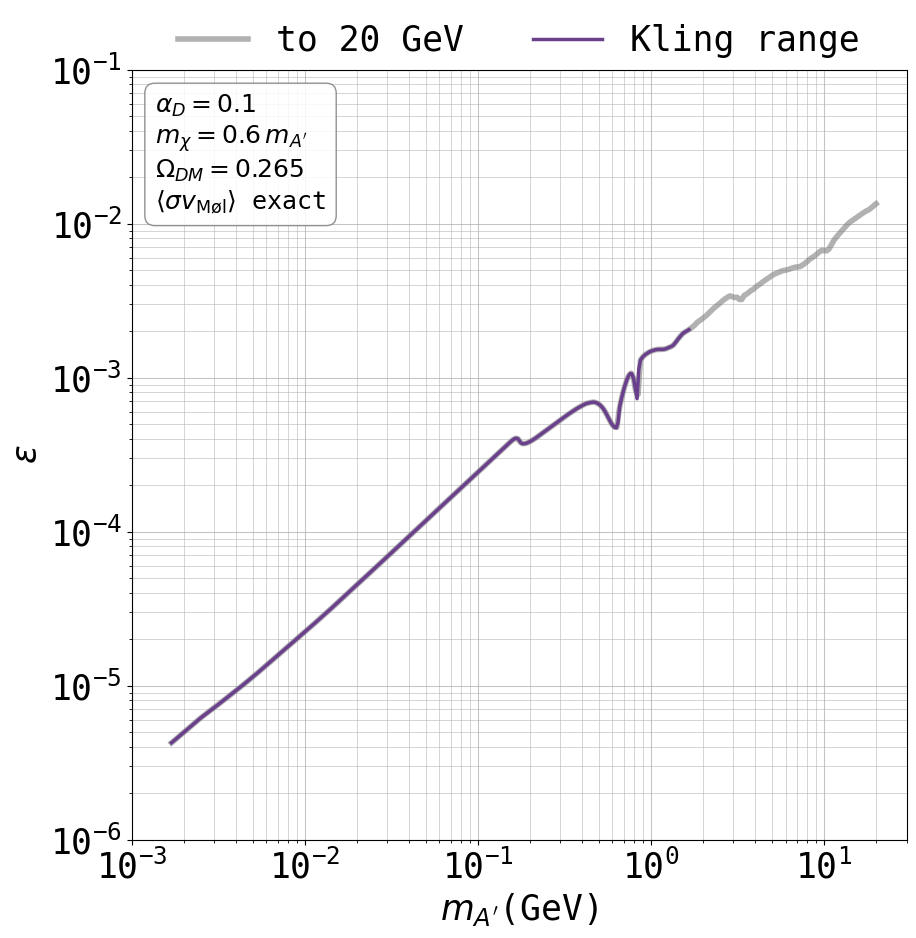

In [287]:
### Confirming the imported line before anything is built on top of it.

# Creating a plot:

fig, ax = plt.subplots(figsize=(10, 10))

ax.set_xlabel(r"$m_{A'}$(GeV)")
ax.set_ylabel(r"$\varepsilon$")

# Log Axis
ax.set_xscale('log')
ax.set_yscale('log')

# Major grid:
ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.75)

# Minor ticks and grid:
ax.minorticks_on()
ax.grid(True, which='minor', linestyle='-', linewidth=0.5, alpha=0.75)

ax.set_axisbelow(True) # Ensure grid is below data

ax.plot(ma_relic_w, eps_relic_w, color = '#7e7e7e', linewidth = 4.0,
        alpha = 0.6, label = r"to 20 GeV")
ax.plot(ma_relic, eps_relic, color = '#6a408d', linewidth = 2.5,
        label = r"Kling range")

ax.text(0.03, 0.97,
        "\n".join([r"$\alpha_D = %g$" % alphaD,
                   r"$m_\chi = %g\, m_{A'}$" % mchi_over_ma,
                   r"$\Omega_{DM} = %s$" % meta_relic["Omega_target"],
                   r"$\left\langle \sigma v_{\rm M\o l} \right\rangle$ exact"]),
        transform = ax.transAxes, va = 'top', ha = 'left', fontsize = 18,
        bbox = dict(boxstyle = 'round,pad=0.4', facecolor = 'white',
                    edgecolor = '#7e7e7e', alpha = 0.85))

# Setting a costumised legend:
handles, labels = ax.get_legend_handles_labels() # get all legend items
desired_order = range(len(handles))  # change the order of legend elements

ax.legend(
    [handles[i] for i in desired_order],
    [labels[i] for i in desired_order],
    loc = 'upper center',
    bbox_to_anchor = (0.5, 1.10),  # center top, above axes
    ncol = 2,                      # spread horizontally
    frameon = False                # removes legend border
)

ax.set_xbound(1e-3, 3e1)
ax.set_ybound(1e-6, 1e-1)

# Save and show the figure:
plt.savefig("figures/relic_line_moller_imported.pdf", bbox_inches='tight')
plt.show()


In [288]:
data_LZ_2024 = np.loadtxt("data/LZ2024_Limit.csv", delimiter=',')

mass_data_LZ_2024 = data_LZ_2024[:, 0]
sigmasidatacm2_LZ_2024 = data_LZ_2024[:, 1]

cm2_to_GeVm2 = 2.5681894616e27          # 1 cm^2 = (hbar c)^-2 GeV^-2
sigmasidataGeV_LZ_2024 = sigmasidatacm2_LZ_2024 * cm2_to_GeVm2

# Interpolating
dd_limit_fun_LZ2024 = interpolate.interp1d(mass_data_LZ_2024, sigmasidataGeV_LZ_2024)

### SI - Interaction cross section

$$
\sigma = \frac{16 \pi \epsilon^2 \alpha \alpha_D}{(\alpha^2 m_e^2 + m_{A'}^2)^2} \mu_{\chi e}
$$

where $\mu_{\chi e}$ is the reduced mass of the DM electron system.

In [289]:
### The theory side: the cross sections an experiment's limit is compared
### against. All three are the same dark photon exchange amplitude, differing
### only in the target and in how the propagator is treated.

def sig_si_theo(ma, alpha, alphaD, mchi, epsilon):
    """SI DM-nucleon cross section in the heavy mediator limit, in GeV^-2."""
    mu = mchi*mp/(mchi + mp)                                   # reduced mass
    return 16*np.pi * epsilon**2 * alpha * alphaD * mu**2 / ma**4

def sig_si_theo_ff(ma, alpha, alphaD, mchi, epsilon, q = None):
    """SI DM-nucleon cross section keeping the mediator propagator at finite q.

    The dark matter form factor F_DM(q) = m_A'^2/(m_A'^2 + q^2) multiplies the
    amplitude, so the cross section carries its square. It reduces to
    sig_si_theo for m_A' >> q and cuts the rate off as (m_A'/q)^4 below it.
    """
    q = q_ref_n if q is None else q
    mu = mchi*mp/(mchi + mp)                                   # reduced mass
    return (16*np.pi * epsilon**2 * alpha * alphaD * mu**2
            / (ma**2 + q**2)**2)

def sig_si_theo_elec(ma, alpha, alphaD, mchi, epsilon):
    """DM-electron cross section in the heavy mediator limit, in GeV^-2.

    Same amplitude with the electron as the target, so only the reduced mass
    changes. The electron recoil transfer q ~ alpha m_e is far below every
    mediator mass here, so the propagator is the heavy one and carries no q.
    """
    mu = mchi*me/(mchi + me)                                   # reduced mass
    return 16*np.pi * epsilon**2 * alpha * alphaD * mu**2 / ma**4

### One helper instead of a per-experiment copy: every limit is the same
### comparison, sigma_theo(epsilon = 1) against a tabulated sigma.

def eps_dd_limit(ma, mchi, mass_tab, sigma_tab, sigma_theo = sig_si_theo,
                 alpha = alpha, alphaD = alphaD):
    """epsilon at which sigma_theo equals the tabulated limit at that mchi.

    Points whose mchi falls outside the tabulated mass range are dropped, so
    the limit is only drawn where the experiment actually constrains it.

    Returns (ma_valid, eps_valid).
    """
    ma, mchi = np.broadcast_arrays(np.atleast_1d(ma), np.atleast_1d(mchi))

    # Keep only the points the interpolator can evaluate:
    inside = (mchi >= mass_tab.min()) & (mchi <= mass_tab.max())
    ma, mchi = ma[inside], mchi[inside]

    # The tabulated limits span decades over few points, so they are read
    # off a log-log interpolation; a linear one overshoots between them.
    sigma_lim = np.exp(np.interp(np.log(mchi), np.log(mass_tab),
                                 np.log(sigma_tab)))
    return ma, np.sqrt(sigma_lim / sigma_theo(ma, alpha, alphaD, mchi, 1.0))

def eps_dd_limit_LZ2024(ma, alpha, alphaD, mchi):
    """epsilon at which sig_si_theo == the LZ 2024 limit at that mchi."""
    return eps_dd_limit(ma, mchi, mass_data_LZ_2024, sigmasidataGeV_LZ_2024,
                        alpha = alpha, alphaD = alphaD)


In [290]:
mlims, eplims =eps_dd_limit_LZ2024(ma_dd, alpha, alphaD, mchi_dd)

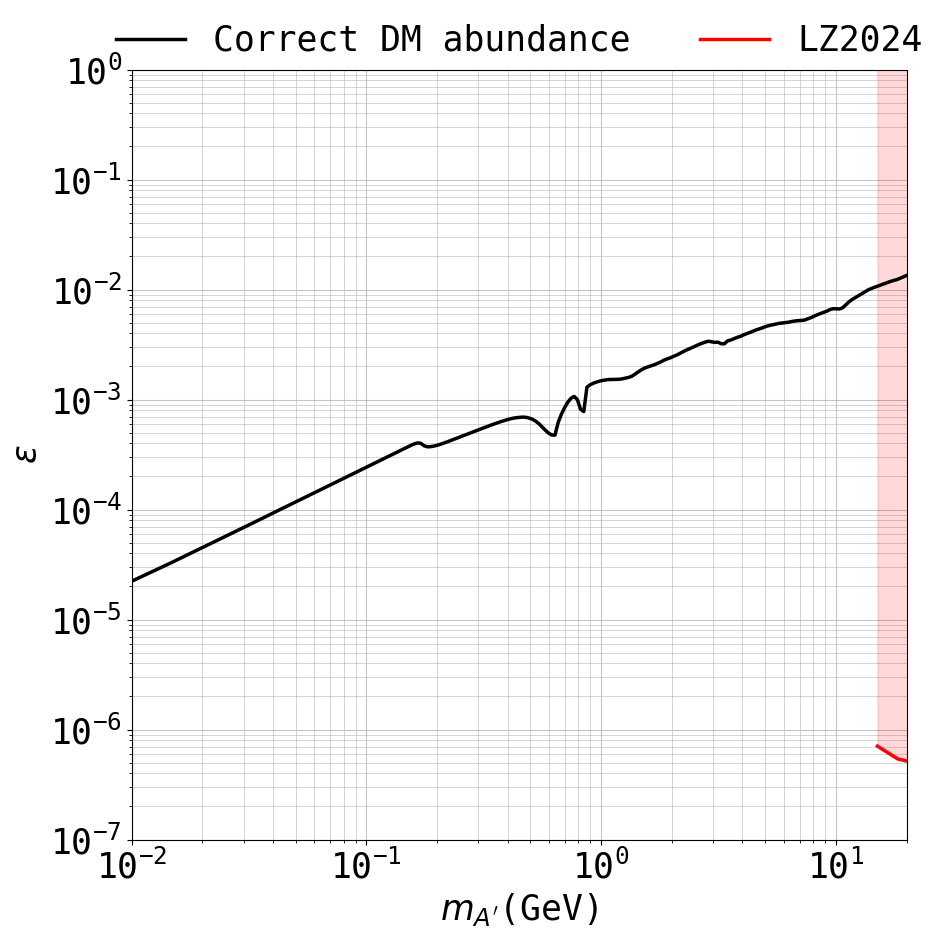

In [291]:
## Creating a plot:

fig, ax = plt.subplots(figsize=(10, 10))

ax.set_xlabel(r"$m_{A'}$(GeV)")
ax.set_ylabel(r"$\epsilon$")

## Log Axis
ax.set_xscale('log')
ax.set_yscale('log')

## Lock the square shape
#ax.set_aspect('equal', adjustable='datalim')

## Major grid:
ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.75)

## Minor ticks and grid:
ax.minorticks_on()
ax.grid(True, which='minor', linestyle='-', linewidth=0.5, alpha=0.75)

ax.set_axisbelow(True) # Ensure grid is below data

ax.plot(ma_relic_w, eps_relic_w, color = 'black', linewidth = 2.5,
        label = r"Correct DM abundance")

ax.plot(mlims, eplims, color = 'red', linewidth = 2.5, label = r"LZ2024")

ax.fill_between(mlims, eplims, 
                1,
                label= rf"Direct detection (Xenon1T)",
                color='red', 
                alpha=0.15, 
                zorder=1)

## Color palets:

dataset_colors = ['#9671bd', '#7e7e7e', '#77b5b6']
dataset_line_colors = ['#6a408d', '#4e4e4e', '#378d94']

# And the colour for the lines (regressions):
regression_color = '#8a8a8a' # <-- neutral grey
# regression_color = '#7f9fa1' # <-- greyish seafoam

'''

ax.scatter(final_data[:,0],final_data[:,1],
            label = "Correct DM abundance",
          s = 90,
          color = dataset_colors[0],
          edgecolors = dataset_line_colors[0],
          linewidths = 1.5,
          zorder = 3
    )

'''

## Setting a costumised legend:
handles, labels = ax.get_legend_handles_labels() # get all legend items
desired_order = [0,1]  # change the order of legend elements


ax.legend(
    [handles[i] for i in desired_order],
    [labels[i] for i in desired_order],
    loc = 'upper center',
    bbox_to_anchor = (0.5, 1.10),  # center top, above axes
    ncol = 4,                      # spread horizontally
    frameon = False                # removes legend border
)

# Define how much to zoom out from the data plotting range (cm):
x_min = 1e-2
x_max = 2e1
x_range = x_max - x_min

y_min = 1e-7
y_max = 1e0
y_range = y_max - y_min

# Set the new plotting limits explicitly
ax.set_xbound(x_min, x_max)
ax.set_ybound(y_min, y_max)


# Save and show the figure:
plt.savefig("figures/relic_abundance_0.pdf", bbox_inches='tight')
plt.show()

In [292]:
### XENONnT SR0+1 SI limit (FIG 3 A of arXiv:2409.17868), from the .npy points

limits_dir_XENONnT = ("data/XENONnT-light_wimp_data_release-64d2e13/"
                      "light_wimp_data_release/limits")

# The published limit is the power-constrained one; the folder also holds
# xenonnt_si_limit_before_pcl.npy and xenonnt_si_limit_after_dl_pcl.npy.
data_XENONnT_si = np.load(f"{limits_dir_XENONnT}/xenonnt_si_limit_after_pcl.npy")

mass_data_XENONnT_si = data_XENONnT_si['mass_gev']
sigmasidatacm2_XENONnT_si = data_XENONnT_si['limit_cm2']

sigmasidataGeV_XENONnT_si = sigmasidatacm2_XENONnT_si * cm2_to_GeVm2

# Interpolating: only 7 tabulated points spanning 5 decades in sigma, so a
# linear interpolation would overshoot by up to ~5x between the low-mass
# points. The limit is close to a straight line in log-log, so interpolate there.
log_dd_limit_XENONnT_si = interpolate.interp1d(np.log(mass_data_XENONnT_si),
                                               np.log(sigmasidataGeV_XENONnT_si))

def dd_limit_fun_XENONnT_si(mchi):
    return np.exp(log_dd_limit_XENONnT_si(np.log(mchi)))

In [293]:
def eps_dd_limit_XENONnT_si(ma, alpha, alphaD, mchi, sigma_theo = sig_si_theo):
    """epsilon at which sigma_theo == the XENONnT SR0+1 SI limit at that mchi.

    Same construction as eps_dd_limit_LZ2024, over the tabulated 3-12 GeV
    range. sigma_theo selects which of the three cross sections the measured
    limit is compared against.

    Returns (ma_valid, eps_valid).
    """
    return eps_dd_limit(ma, mchi, mass_data_XENONnT_si, sigmasidataGeV_XENONnT_si,
                        sigma_theo = sigma_theo, alpha = alpha, alphaD = alphaD)


In [294]:
mlims_XENONnT, eplims_XENONnT = eps_dd_limit_XENONnT_si(ma_dd, alpha, alphaD,
                                                       mchi_dd)

### The same limit read against the other two cross sections. Only the theory
### side changes, so the three curves differ by exactly the propagator and
### reduced mass factors between them.

mlims_XENONnT_ff, eplims_XENONnT_ff = eps_dd_limit_XENONnT_si(
    ma_dd, alpha, alphaD, mchi_dd, sigma_theo = sig_si_theo_ff)

mlims_XENONnT_e, eplims_XENONnT_e = eps_dd_limit_XENONnT_si(
    ma_dd, alpha, alphaD, mchi_dd, sigma_theo = sig_si_theo_elec)


In [295]:
### XENON1T 2018 SI limit, data/Xenon1T-2018-limit.txt.

# Two columns, mchi in GeV and sigma_SI in cm^2, 28 points over 5.9-1000 GeV.

data_XENON1T = np.loadtxt("data/Xenon1T-2018-limit.txt")

mass_data_XENON1T = data_XENON1T[:, 0]
sigmasidataGeV_XENON1T = data_XENON1T[:, 1] * cm2_to_GeVm2

mlims_XENON1T, eplims_XENON1T = eps_dd_limit(ma_dd, mchi_dd, mass_data_XENON1T,
                                             sigmasidataGeV_XENON1T)

mlims_XENON1T_ff, eplims_XENON1T_ff = eps_dd_limit(
    ma_dd, mchi_dd, mass_data_XENON1T, sigmasidataGeV_XENON1T,
    sigma_theo = sig_si_theo_ff)

### And LZ against the form factor cross section, for the same comparison.

mlims_ff, eplims_ff = eps_dd_limit(ma_dd, mchi_dd, mass_data_LZ_2024,
                                   sigmasidataGeV_LZ_2024,
                                   sigma_theo = sig_si_theo_ff)


## FORESEE results: starting point

In [296]:
### Kling's own direct detection bound, data/Kling/bounds_DD.txt.

# Already an exclusion contour in the (m_A', epsilon) plane rather than a
# sigma_SI(mchi) limit, so it needs no reinterpretation: it was drawn for the
# same model, alphaD = 0.1 and mchi = 0.6 m_A' (recovered from the relic file
# in the same folder). It is a closed polygon whose first and last vertices
# are pulled up to epsilon = 1, i.e. the region above the curve is excluded.

bounds_DD_kling = np.loadtxt("data/Kling/bounds_DD.txt")

ma_DD_kling  = bounds_DD_kling[:, 0]
eps_DD_kling = bounds_DD_kling[:, 1]

# The two vertical closure segments are an artefact of closing the polygon,
# so the boundary itself is drawn without them.
ma_DD_kling_line  = ma_DD_kling[1:-1]
eps_DD_kling_line = eps_DD_kling[1:-1]


In [297]:
### The pieces of Kling's combined direct detection contour,
### data/Kling/DD_separate/*.txt.

# Five files, each a published limit in its own units rather than an
# (m_A', epsilon) contour, so each has to be reinterpreted the same way the
# LZ and XENONnT limits are. Only XENON1T-Migdal is kept: it is the one whose
# reinterpretation lands on bounds_DD.txt (ratio to it 1.02 median, 0.92-1.1
# over most of the range). The other four are electron recoil sigma_e limits
# (XENON10, XENON10_heavy, XENON100_heavy) or an eV-mass absorption limit
# (Xenon1TS2Only). None of them ever falls below the combined line, so none
# sets any part of it: the closest, XENON10_heavy, tracks it within a factor
# 1.2-1.9 below m_A' = 0.05 GeV and then runs away to 1e3 times it by 1 GeV,
# with XENON100_heavy a further factor 4 above that. Both are superseded by
# Xenon10and100.csv, read in the cell below, which is modestly stronger than
# either but still does not bound the model.

# Two columns, mchi in GeV and sigma_SI in cm^2, 64 points over 0.10-4.9 GeV;
# a nucleon limit, so it uses the same sig_si_theo as the other SI datasets.

data_XENON1T_migdal = np.loadtxt("data/Kling/DD_separate/XENON1T-Migdal.txt")

mass_data_XENON1T_migdal = data_XENON1T_migdal[:, 0]
sigmasidataGeV_XENON1T_migdal = data_XENON1T_migdal[:, 1] * cm2_to_GeVm2

mlims_migdal, eplims_migdal = eps_dd_limit(ma_dd, mchi_dd,
                                           mass_data_XENON1T_migdal,
                                           sigmasidataGeV_XENON1T_migdal)


In [298]:
### The combined XENON10 + XENON100 electron recoil limit,
### data/Kling/DD_separate/Xenon10and100.csv.

# Two comma separated columns, mchi in MeV and sigma_e in cm^2, 43 points
# over 8.9 MeV - 2.99 GeV, most sensitive at mchi = 178 MeV. It supersedes
# the two per-experiment files in the same folder, XENON10_heavy.txt and
# XENON100_heavy.txt, which are left unread: over the range all three share
# it sits just below both (median 0.74 of XENON10, 0.59 of XENON100), which
# is what a combined limit should do.

# It does not bound this model, but unlike the other electron files it comes
# close enough to be worth drawing against Kling's contour, so it appears in
# both planes. Read against sig_si_theo_elec it comes within
# 1.02 of Kling's combined contour at m_A' = 0.037 GeV and tracks it within
# 1.02-1.31 from 0.015 to 0.037 GeV, but never crosses below it, and its
# closest approach to the relic line is a factor 2.46 at m_A' = 0.029 GeV.

MeV_to_GeV = 1e-3

data_xe10and100 = np.loadtxt("data/Kling/DD_separate/Xenon10and100.csv",
                             delimiter = ",")

mass_data_xe10and100 = data_xe10and100[:, 0]*MeV_to_GeV
sigmaedatacm2_xe10and100 = data_xe10and100[:, 1]
sigmaedataGeV_xe10and100 = sigmaedatacm2_xe10and100 * cm2_to_GeVm2

mlims_xe10and100, eplims_xe10and100 = eps_dd_limit(
    ma_dd, mchi_dd, mass_data_xe10and100, sigmaedataGeV_xe10and100,
    sigma_theo = sig_si_theo_elec)
### XENON1T's own electron recoil limit, data/Kling/DD_separate/XENON1T.txt.

# Same two columns, mchi in MeV and sigma_e in cm^2, 52 points over
# 19.6 MeV - 1.01 GeV, most sensitive at mchi = 210 MeV where it reaches
# 1.1e-40 cm^2. Its first header line reads XENON100, which is a copy and
# paste slip: the paper it cites, arXiv:1907.11485, is XENON1T.

# It is the strongest electron recoil limit in the folder by a wide margin,
# a median factor 0.016 of XENON10 + XENON100 in sigma, and it is the only
# one of them that bounds this model: read against sig_si_theo_elec it falls
# below the relic line over m_A' = 0.067-0.317 GeV, reaching 0.47 of it at
# 0.14 GeV. Against Kling's contour it comes to 1.01 at m_A' = 0.21 GeV but
# stays above it, so it is not what that contour was drawn from either.

data_xe1t_e = np.genfromtxt("data/Kling/DD_separate/XENON1T.txt",
                            comments = "#")

mass_data_xe1t_e = data_xe1t_e[:, 0]*MeV_to_GeV
sigmaedataGeV_xe1t_e = data_xe1t_e[:, 1] * cm2_to_GeVm2

mlims_xe1t_e, eplims_xe1t_e = eps_dd_limit(
    ma_dd, mchi_dd, mass_data_xe1t_e, sigmaedataGeV_xe1t_e,
    sigma_theo = sig_si_theo_elec)


In [299]:
### The accelerator and beam dump bounds, data/Kling/Lines/bounds_*.txt.

# Sixteen files, same two column (m_A', epsilon) format as bounds_DD.txt and
# the same model assumptions, each a closed polygon bounding an excluded
# region. Several close themselves at epsilon = 1e5, far above the axes, which
# is why they are drawn as filled polygons rather than as curves against a
# ceiling.

import glob
import os

bounds_lines = {}
for path in sorted(glob.glob("data/Kling/Lines/bounds_*.txt")):
    name = os.path.basename(path)[len("bounds_"):-len(".txt")]
    bounds_lines[name] = np.loadtxt(path)


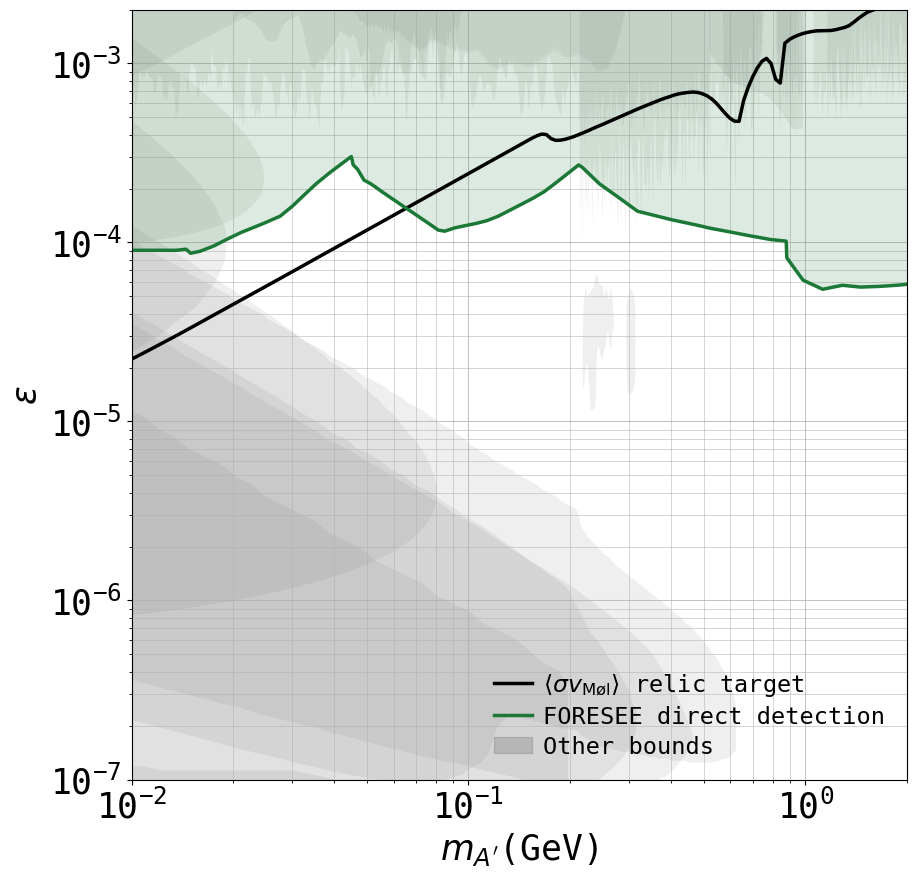

In [300]:
## Creating a plot:

fig, ax = plt.subplots(figsize=(10, 10))

ax.set_xlabel(r"$m_{A'}$(GeV)")
ax.set_ylabel(r"$\epsilon$")

## Log Axis
ax.set_xscale('log')
ax.set_yscale('log')

## Major grid:
ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.75)

## Minor ticks and grid:
ax.minorticks_on()
ax.grid(True, which='minor', linestyle='-', linewidth=0.5, alpha=0.75)

ax.set_axisbelow(True) # Ensure grid is below data

ax.plot(ma_relic_w, eps_relic_w, color = 'black', linewidth = 2.5,
        label = r"$\left\langle \sigma v_{\rm M\o l} \right\rangle$ relic target")

ax.plot(mlims, eplims, color = 'red', linewidth = 2.5)

ax.fill_between(mlims, eplims,
                1,
                color='red',
                alpha=0.15,
                zorder=1)

ax.plot(mlims_XENONnT, eplims_XENONnT,
        color = '#2a78d6', linewidth = 2.5)

ax.fill_between(mlims_XENONnT, eplims_XENONnT,
                1,
                color='#2a78d6',
                alpha=0.15,
                zorder=1)

# All sixteen shaded as one grey family: individually they would need
# sixteen legend entries and would bury the direct detection lines, and what
# matters here is only which part of the plane they already cover.
for _name, _b in bounds_lines.items():
    ax.fill(_b[:, 0], _b[:, 1], color = '#7e7e7e', alpha = 0.12,
            linewidth = 0, zorder = 0)

# One proxy handle for the family as a whole.
ax.fill(np.nan, np.nan, color = '#7e7e7e', alpha = 0.35,
        label = r"Other bounds")

ax.plot(ma_DD_kling_line, eps_DD_kling_line,
        color = '#1b7837', linewidth = 2.5, label = r"FORESEE direct detection")

ax.fill(ma_DD_kling, eps_DD_kling,
        color = '#1b7837',
        alpha = 0.15,
        zorder = 1)

## Setting a costumised legend:
handles, labels = ax.get_legend_handles_labels() # get all legend items
desired_order = [0,2,1]  # change the order of legend elements

ax.legend(
    [handles[i] for i in desired_order],
    [labels[i] for i in desired_order],
    loc = 'lower right',           # the lower right of the axes is empty
    ncol = 1,                      # stacked, to keep it narrow
    fontsize = 17,
    labelspacing = 0.3,
    handlelength = 1.6,
    handletextpad = 0.5,
    borderpad = 0.4,
    frameon = False                # removes legend border
)

# Define how much to zoom out from the data plotting range (cm):
x_min = 1e-2
x_max = 2e0

y_min = 1e-7
y_max = 2e-3

# Set the new plotting limits explicitly
ax.set_xbound(x_min, x_max)
ax.set_ybound(y_min, y_max)

# Save and show the figure:
plt.savefig("figures/relic_abundance_XENONnT_LZ.pdf", bbox_inches='tight')
plt.show()

## Breaking appart the direct detection line:

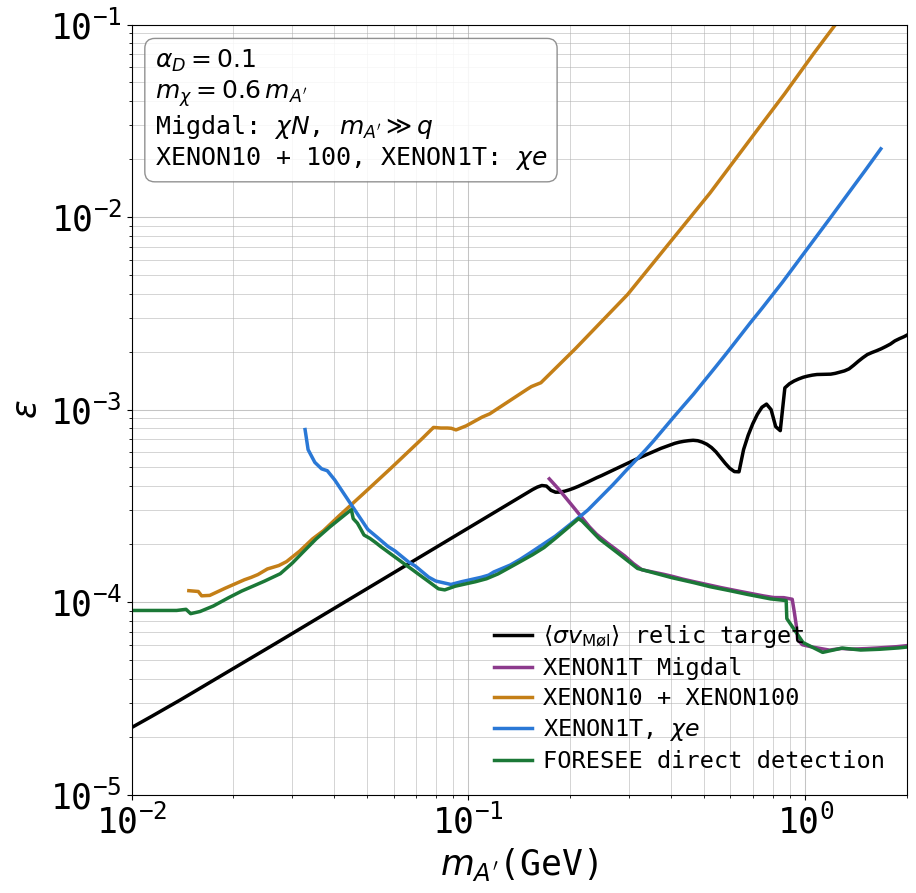

In [301]:
### The two DD_separate datasets that were reinterpreted for this model,
### against the contour Kling drew from them. Both are read at epsilon = 1
### and inverted, the Migdal one against the nucleon cross section and the
### electron recoil one against sig_si_theo_elec, so what is being compared
### is the reinterpretation itself: Kling's line is the same measurements
### passed through his own.

# Creating a plot:

fig, ax = plt.subplots(figsize=(10, 10))

ax.set_xlabel(r"$m_{A'}$(GeV)")
ax.set_ylabel(r"$\varepsilon$")

# Log Axis
ax.set_xscale('log')
ax.set_yscale('log')

# Major grid:
ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.75)

# Minor ticks and grid:
ax.minorticks_on()
ax.grid(True, which='minor', linestyle='-', linewidth=0.5, alpha=0.75)

ax.set_axisbelow(True) # Ensure grid is below data

# The relic target the limits are being set against.
ax.plot(ma_relic_w, eps_relic_w, color = 'black', linewidth = 2.5,
        label = r"$\left\langle \sigma v_{\rm M\o l} \right\rangle$ relic target")

# The nucleon reading, which lands on Kling's contour above 0.17 GeV.
ax.plot(mlims_migdal, eplims_migdal, color = '#8c3a8c', linewidth = 2.5,
        label = r"XENON1T Migdal")

# The electron reading, which covers the masses below that but stays above
# the contour everywhere, coming within 1.02 of it at m_A' = 0.037 GeV.
ax.plot(mlims_xe10and100, eplims_xe10and100, color = '#c47f17',
        linewidth = 2.5, label = r"XENON10 + XENON100")

# The XENON1T electron recoil limit, the one dataset here that cuts into the
# relic line, over m_A' = 0.067-0.317 GeV.
ax.plot(mlims_xe1t_e, eplims_xe1t_e, color = '#2a78d6', linewidth = 2.5,
        label = r"XENON1T, $\chi e$")

ax.plot(ma_DD_kling_line, eps_DD_kling_line, color = '#1b7837',
        linewidth = 2.5, label = r"FORESEE direct detection")

ax.text(0.03, 0.97,
        "\n".join([r"$\alpha_D = %g$" % alphaD,
                   r"$m_\chi = %g\, m_{A'}$" % mchi_over_ma,
                   r"Migdal: $\chi N$, $m_{A'} \gg q$",
                   r"XENON10 + 100, XENON1T: $\chi e$"]),
        transform = ax.transAxes, va = 'top', ha = 'left', fontsize = 18,
        bbox = dict(boxstyle = 'round,pad=0.4', facecolor = 'white',
                    edgecolor = '#7e7e7e', alpha = 0.85))

# Setting a costumised legend:
handles, labels = ax.get_legend_handles_labels() # get all legend items
desired_order = range(len(handles))  # change the order of legend elements

ax.legend(
    [handles[i] for i in desired_order],
    [labels[i] for i in desired_order],
    loc = 'lower right',           # the lower right of the axes is empty
    ncol = 1,                      # stacked, to keep it narrow
    fontsize = 17,
    labelspacing = 0.3,
    handlelength = 1.6,
    handletextpad = 0.5,
    borderpad = 0.4,
    frameon = False                # removes legend border
)

x_min = 1e-2
x_max = 2e0

y_min = 1e-5
y_max = 1e-1

ax.set_xbound(x_min, x_max)
ax.set_ybound(y_min, y_max)

# Save and show the figure:
plt.savefig("figures/direct_detection_breakdown.pdf", bbox_inches='tight')
plt.show()
